<a href="https://colab.research.google.com/github/paulorsf29/Portifolio_ProcessamentoDeImagens/blob/main/Portifolio02_histogramas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
img1 = cv2.imread('img1.jpeg')
img2 = cv2.imread('img2.jpeg')
img3 = cv2.imread('img3.jpeg')


In [5]:
img_gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img_gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
img_gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

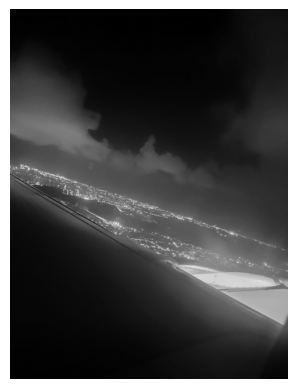

In [9]:
plt.imshow(img_gray1, cmap='gray')
plt.axis('off')
plt.show()

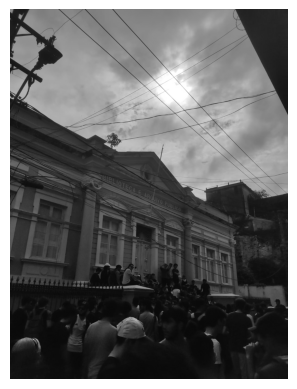

In [10]:
plt.imshow(img_gray2, cmap='gray')
plt.axis('off')
plt.show()

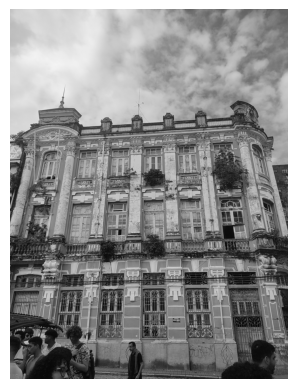

In [11]:
plt.imshow(img_gray3, cmap='gray')
plt.axis('off')
plt.show()

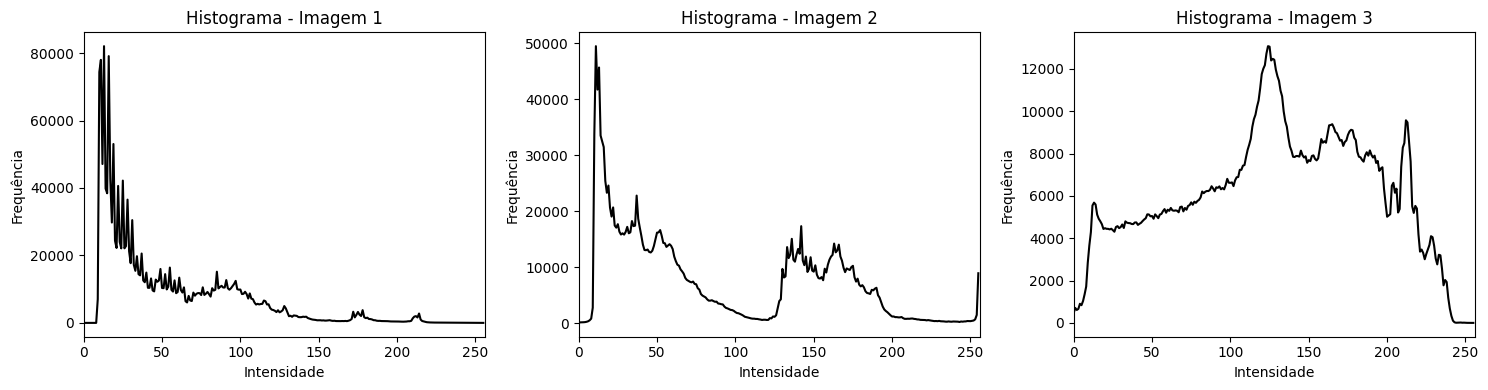

In [12]:
imgs_gray = [img_gray1, img_gray2, img_gray3]
titulos = ["Imagem 1", "Imagem 2", "Imagem 3"]

plt.figure(figsize=(15, 4))

for i, (gray, titulo) in enumerate(zip(imgs_gray, titulos)):
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    plt.subplot(1, 3, i + 1)
    plt.plot(hist, color='black')
    plt.title(f"Histograma - {titulo}")
    plt.xlabel("Intensidade")
    plt.ylabel("Frequência")
    plt.xlim([0, 256])

plt.tight_layout()
plt.show()

 Em nas imagens 1 (noturna) e 2 de dia sombriado da pra perceber uma predominancia pela itensidade mais escura proxima de 0 com exceção da imagem 3 que mesmo em tons de cinza tem seu predominio na na faixa 100 a 200 de intensidade.

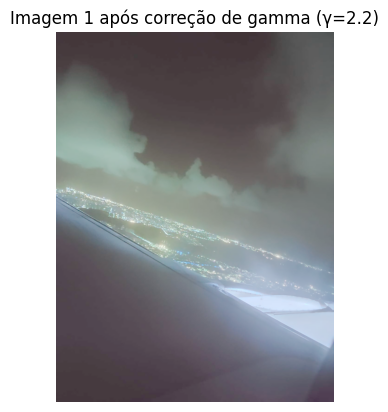

In [15]:
def corrigir_gamma(gray, gamma=1.0):
    """Correção de gamma via cv2.LUT.
    saída = 255 * (entrada/255) ** (1/gamma)
    gamma > 1 clareia a imagem; gamma < 1 escurece."""

    inv_gamma = 1.0 / gamma
    tabela = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(gray, tabela)

# Parâmetro escolhido: gamma = 2.2 (clareia as sombras)
gamma1 = 2.2
img1_gamma = corrigir_gamma(img1, gamma=gamma1)

# Mostrando o resultado
plt.imshow(img1_gamma, cmap='gray', vmin=0, vmax=255)
plt.title(f"Imagem 1 após correção de gamma (γ={gamma1})")
plt.axis('off')
plt.show()

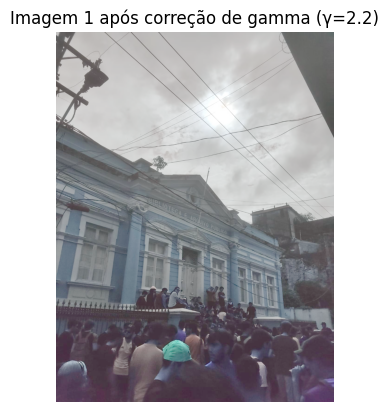

In [19]:
def corrigir_gamma(gray, gamma=1.0):
    """Correção de gamma via cv2.LUT.
    saída = 255 * (entrada/255) ** (1/gamma)
    gamma > 1 clareia a imagem; gamma < 1 escurece."""

    inv_gamma = 1.0 / gamma
    tabela = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(gray, tabela)

# Parâmetro escolhido: gamma = 2.2 (clareia as sombras)
gamma1 = 2.2
img1_gamma = corrigir_gamma(img2, gamma=gamma1)

# Mostrando o resultado
plt.imshow(img1_gamma, cmap='gray', vmin=0, vmax=255)
plt.title(f"Imagem 1 após correção de gamma (γ={gamma1})")
plt.axis('off')
plt.show()

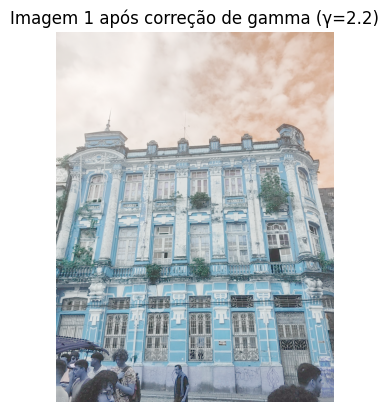

In [20]:
def corrigir_gamma(gray, gamma=1.0):
    """Correção de gamma via cv2.LUT.
    saída = 255 * (entrada/255) ** (1/gamma)
    gamma > 1 clareia a imagem; gamma < 1 escurece."""

    inv_gamma = 1.0 / gamma
    tabela = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(gray, tabela)

# Parâmetro escolhido: gamma = 2.2 (clareia as sombras)
gamma1 = 2.2
img1_gamma = corrigir_gamma(img3, gamma=gamma1)

# Mostrando o resultado
plt.imshow(img1_gamma, cmap='gray', vmin=0, vmax=255)
plt.title(f"Imagem 1 após correção de gamma (γ={gamma1})")
plt.axis('off')
plt.show()

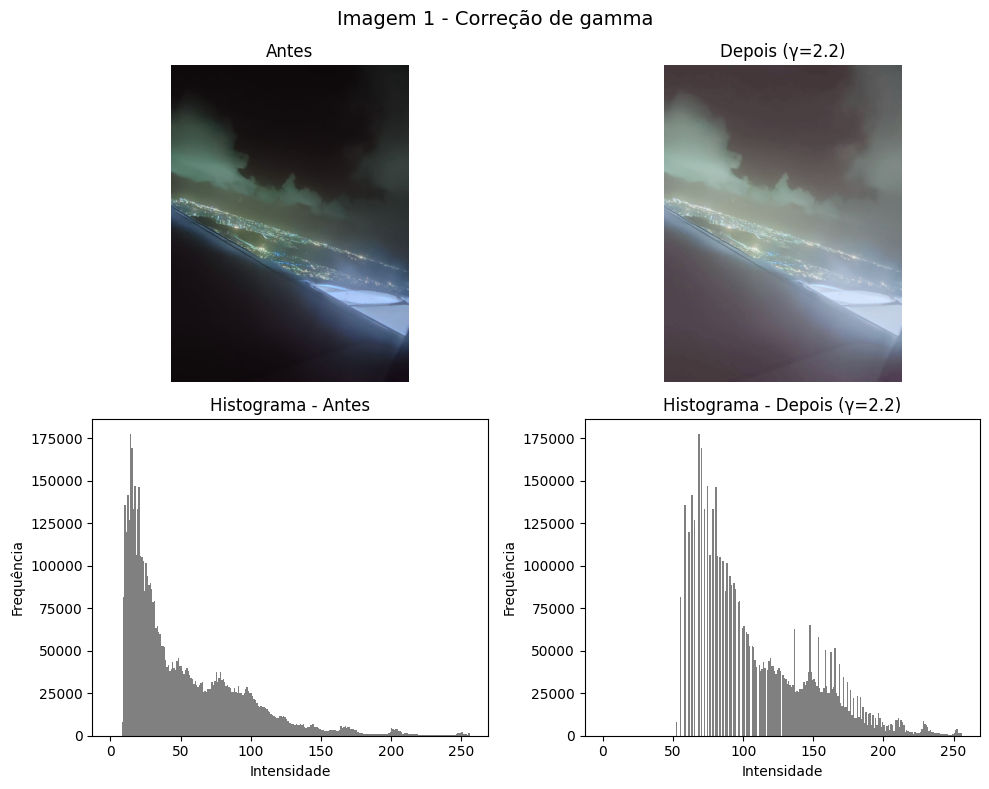

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Imagem antes
axs[0, 0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axs[0, 0].set_title("Antes")
axs[0, 0].axis('off')

# Imagem depois (correção de gamma)
axs[0, 1].imshow(img1_gamma, cmap='gray', vmin=0, vmax=255)
axs[0, 1].set_title(f"Depois (γ={gamma1})")
axs[0, 1].axis('off')

# Histograma antes
axs[1, 0].hist(img1.ravel(), bins=256, range=(0, 256), color='gray')
axs[1, 0].set_title("Histograma - Antes")
axs[1, 0].set_xlabel("Intensidade")
axs[1, 0].set_ylabel("Frequência")

# Histograma depois
axs[1, 1].hist(img1_gamma.ravel(), bins=256, range=(0, 256), color='gray')
axs[1, 1].set_title(f"Histograma - Depois (γ={gamma1})")
axs[1, 1].set_xlabel("Intensidade")
axs[1, 1].set_ylabel("Frequência")

fig.suptitle("Imagem 1 - Correção de gamma", fontsize=14)
plt.tight_layout()
plt.show()

o operação de correção de gama teve menos efeito na imagen 2 que é medianamente clara. com mais brilho de gama apenas tornou a imagem um pouco mais clara diferente da imagen 1 que quando incluido o gama apareceu campos e locais que não estavam viziveis antes pela escuridão da imagem